# Order Lifecycle State Machine

**Docker image**: `ml4t`

**Chapter 25: Live Trading Systems**
**Section Reference**: See Section 25.5 (Order Lifecycle Management) for conceptual discussion

## Purpose
Visualizes and implements the order lifecycle as a finite state machine.

## Implementation Skills
- How to model order states and transitions
- How to handle partial fills and cancellations
- How to separate in-memory lifecycle validation from durable recovery controls
- How to maintain audit trails for compliance

**Learning Objectives**
- Map broker events onto a finite set of valid order states.
- Identify which transitions are safe, terminal, or operationally ambiguous.
- Read state logs as a reconciliation tool rather than as a mere implementation detail.

**Prerequisites**
- Review Chapter 25.5 on broker acknowledgments, partial fills, and cancel/replace workflows.
- Familiarity with why production audit trails need durable storage beyond this in-memory demo.

Understanding state transitions is critical for:

1. **Correct Order Handling**: Know when orders can be modified or canceled
2. **Error Recovery**: Handle rejected or failed orders gracefully
3. **Reconciliation**: Track order progression through the system
4. **Audit Trails**: Log all state transitions for compliance

## Order Lifecycle Overview

Figure 25.2 in the book contains the full state graph. The notebook later
renders selected operator paths; the transition table remains authoritative.

In [1]:
"""Model order states, transitions, and audit trails."""

import math
import warnings
from collections.abc import Callable
from dataclasses import dataclass, field
from datetime import datetime
from enum import Enum, auto

import matplotlib.patches as mpatches

# Visualization
import matplotlib.pyplot as plt
import polars as pl

from utils.style import COLORS, FIGSIZE, add_message_title

# matplotlibrc in repo root handles styling

warnings.filterwarnings("ignore")

## 1. Order States Definition

Order states follow exchange/broker conventions. Each state has specific properties regarding what actions are allowed.

In [2]:
# compliance: skip cell_size - one Enum definition with three property helpers
class OrderState(Enum):
    """All possible order states in the lifecycle."""

    # Initial states
    PENDING_NEW = auto()  # Order submitted, awaiting broker acknowledgment
    NEW = auto()  # Order acknowledged by broker

    # Active states
    ACCEPTED = auto()  # Order accepted by exchange
    PARTIALLY_FILLED = auto()  # Some quantity executed

    # Modification states
    PENDING_CANCEL = auto()  # Cancel request submitted

    # Terminal states (no further transitions)
    FILLED = auto()  # Fully executed
    CANCELED = auto()  # Successfully canceled
    REJECTED = auto()  # Rejected by broker/exchange
    EXPIRED = auto()  # Time-in-force expired
    SUSPENDED = auto()  # Trading halted

    @property
    def is_terminal(self) -> bool:
        """Check if this is a terminal (final) state."""
        return self in {
            OrderState.FILLED,
            OrderState.CANCELED,
            OrderState.REJECTED,
            OrderState.EXPIRED,
        }

    @property
    def is_active(self) -> bool:
        """Check if order is active (can be filled)."""
        return self in {
            OrderState.NEW,
            OrderState.ACCEPTED,
            OrderState.PARTIALLY_FILLED,
        }

    @property
    def can_cancel(self) -> bool:
        """Check if order can be canceled."""
        return self in {
            OrderState.NEW,
            OrderState.ACCEPTED,
            OrderState.PARTIALLY_FILLED,
            OrderState.SUSPENDED,
        }

In [3]:
state_properties = pl.DataFrame(
    [
        {
            "state": s.name,
            "terminal": s.is_terminal,
            "active": s.is_active,
            "can_cancel": s.can_cancel,
        }
        for s in OrderState
    ]
)
state_properties

state,terminal,active,can_cancel
str,bool,bool,bool
"""PENDING_NEW""",false,false,false
"""NEW""",false,true,true
"""ACCEPTED""",false,true,true
"""PARTIALLY_FILLED""",false,true,true
"""PENDING_CANCEL""",false,false,false
"""FILLED""",true,false,false
"""CANCELED""",true,false,false
"""REJECTED""",true,false,false
"""EXPIRED""",true,false,false


**Finding:** The state-property table above makes the operational constraint explicit: not every visible
order can be modified or canceled. That is why a live system needs state-aware logic instead of simple
boolean flags like "open" or "closed."

## 2. State Transition Rules

Define valid transitions between states and make invalid paths explicit. In a live system, rejecting an
illegal transition early is safer than inferring intent from inconsistent broker callbacks.

In [4]:
class OrderEvent(Enum):
    """Events that trigger state transitions."""

    ACKNOWLEDGE = auto()  # Broker acknowledges order
    ACCEPT = auto()  # Exchange accepts order
    PARTIAL_FILL = auto()  # Partial execution
    FILL = auto()  # Full execution
    CANCEL_REQUEST = auto()  # Cancel requested
    CANCEL_CONFIRM = auto()  # Cancel confirmed
    REJECT = auto()  # Order rejected
    EXPIRE = auto()  # Time-in-force expired
    SUSPEND = auto()  # Trading suspended

### Transition Table

`VALID_TRANSITIONS` maps each `(state, event)` pair to the next state. Terminal states have an empty
transition dictionary, which is the explicit way to say "no outgoing edges." `SUSPENDED` is the one
non-terminal state with an unusual exit profile: trading can resume (back to `ACCEPTED`) or the order can
still be canceled.

Replace flows (modifying an open order's price or quantity) are intentionally **out of scope** for this
teaching notebook. Production replace handling lives in `ml4t.live.safety`, where it is layered on top of
the lifecycle below; conflating it with the core transitions hides the audit story.

In [5]:
# compliance: skip cell_size - one dict literal expressing the state-machine edges
VALID_TRANSITIONS: dict[OrderState, dict[OrderEvent, OrderState]] = {
    OrderState.PENDING_NEW: {
        OrderEvent.ACKNOWLEDGE: OrderState.NEW,
        OrderEvent.REJECT: OrderState.REJECTED,
    },
    OrderState.NEW: {
        OrderEvent.ACCEPT: OrderState.ACCEPTED,
        OrderEvent.REJECT: OrderState.REJECTED,
        OrderEvent.FILL: OrderState.FILLED,
        OrderEvent.CANCEL_REQUEST: OrderState.PENDING_CANCEL,
    },
    OrderState.ACCEPTED: {
        OrderEvent.PARTIAL_FILL: OrderState.PARTIALLY_FILLED,
        OrderEvent.FILL: OrderState.FILLED,
        OrderEvent.CANCEL_REQUEST: OrderState.PENDING_CANCEL,
        OrderEvent.EXPIRE: OrderState.EXPIRED,
        OrderEvent.SUSPEND: OrderState.SUSPENDED,
    },
    OrderState.PARTIALLY_FILLED: {
        OrderEvent.PARTIAL_FILL: OrderState.PARTIALLY_FILLED,
        OrderEvent.FILL: OrderState.FILLED,
        OrderEvent.CANCEL_REQUEST: OrderState.PENDING_CANCEL,
    },
    OrderState.PENDING_CANCEL: {
        OrderEvent.CANCEL_CONFIRM: OrderState.CANCELED,
        OrderEvent.FILL: OrderState.FILLED,  # Can fill before cancel confirms
        OrderEvent.REJECT: OrderState.ACCEPTED,  # Cancel rejected, back to active
    },
    # Terminal states have no outgoing transitions
    OrderState.FILLED: {},
    OrderState.CANCELED: {},
    OrderState.REJECTED: {},
    OrderState.EXPIRED: {},
    OrderState.SUSPENDED: {
        OrderEvent.ACCEPT: OrderState.ACCEPTED,  # Resume after suspension
        OrderEvent.CANCEL_REQUEST: OrderState.PENDING_CANCEL,
    },
}

### The PENDING_CANCEL Race

Look at the three outgoing edges from `PENDING_CANCEL`: the order can confirm the cancel
(`CANCEL_CONFIRM` to `CANCELED`), but it can equally fill before the cancel reaches the matching engine
(`FILL` to `FILLED`), or have the cancel rejected and snap back to `ACCEPTED`. This is the classic race
between a cancel request in flight and a fill landing on the original order. A naive implementation that
marks the order canceled on `CANCEL_REQUEST` would silently disagree with the broker's books whenever the
fill wins; the explicit `PENDING_CANCEL` state turns the race into a normal transition rather than a
reconciliation incident.

### Valid Events Helper

This helper exposes the legal events from each current state so operators can diagnose whether an incoming
broker update is expected, delayed, or structurally impossible.

In [6]:
def get_valid_events(state: OrderState) -> list[OrderEvent]:
    """Get valid events for a given state."""
    return list(VALID_TRANSITIONS.get(state, {}).keys())


valid_events = pl.DataFrame(
    [
        {
            "state": s.name,
            "valid_events": ", ".join(e.name for e in get_valid_events(s)) or "(terminal)",
        }
        for s in OrderState
    ]
)
valid_events

state,valid_events
str,str
"""PENDING_NEW""","""ACKNOWLEDGE, REJECT"""
"""NEW""","""ACCEPT, REJECT, FILL, CANCEL_R…"
"""ACCEPTED""","""PARTIAL_FILL, FILL, CANCEL_REQ…"
"""PARTIALLY_FILLED""","""PARTIAL_FILL, FILL, CANCEL_REQ…"
"""PENDING_CANCEL""","""CANCEL_CONFIRM, FILL, REJECT"""
"""FILLED""","""(terminal)"""
"""CANCELED""","""(terminal)"""
"""REJECTED""","""(terminal)"""
"""EXPIRED""","""(terminal)"""


**Finding:** The valid-event listing is the notebook's first reconciliation aid. It shows exactly which
state transitions are legal, so any unexpected broker callback can be diagnosed as either a valid ordering
anomaly (e.g., ack-lag) or a real bug.

## 3. Order State Machine Implementation

The state machine enforces valid transitions and maintains audit history.

This is the bridge from abstract workflow diagrams to code that validates real broker callbacks. The
in-memory log supports a single process; durable persistence and idempotent replay for crash recovery are
production controls outside this notebook's scope.

In [7]:
@dataclass
class StateTransition:
    """Record of a state transition."""

    timestamp: datetime
    from_state: OrderState
    to_state: OrderState
    event: OrderEvent
    metadata: dict = field(default_factory=dict)

### Stateful Order

The order object enforces valid transitions and preserves history.

This object is intentionally explicit about state, fills, and callbacks because live order management fails
when those concerns are hidden behind loosely coupled flags.

In [8]:
# compliance: skip cell_size - one dataclass owns transition and fill invariants
@dataclass
class Order:
    """Order with state machine behavior."""

    id: str
    symbol: str
    side: str
    qty: float
    order_type: str

    # State tracking
    state: OrderState = OrderState.PENDING_NEW
    history: list[StateTransition] = field(default_factory=list)

    # Execution tracking
    filled_qty: float = 0
    avg_fill_price: float | None = None

    # Callbacks
    on_transition: "Callable[[Order, StateTransition], None] | None" = None

    def __post_init__(self) -> None:
        if not math.isfinite(self.qty) or self.qty <= 0:
            raise ValueError("Order quantity must be finite and positive")

    def apply_event(
        self,
        event: OrderEvent,
        metadata: dict | None = None,
    ) -> OrderState:
        """
        Apply an event to trigger state transition.

        Parameters
        ----------
        event : OrderEvent
            The event to apply
        metadata : dict, optional
            Additional data (e.g., fill price, quantity)

        Returns
        -------
        OrderState
            The new state after transition

        Raises
        ------
        ValueError
            If transition is invalid
        """
        valid_events = VALID_TRANSITIONS.get(self.state, {})

        if event not in valid_events:
            raise ValueError(
                f"Invalid transition: {self.state.name} + {event.name}. "
                f"Valid events: {[e.name for e in valid_events.keys()]}"
            )

        metadata_snapshot = dict(metadata or {})
        fill = self._validate_fill(event, metadata_snapshot)
        old_state = self.state
        new_state = valid_events[event]

        # Create transition record
        transition = StateTransition(
            timestamp=datetime.now(),
            from_state=old_state,
            to_state=new_state,
            event=event,
            metadata=metadata_snapshot,
        )

        # Commit state, history, and fill accounting only after every invariant
        # has passed. Invalid fill metadata therefore leaves the order unchanged.
        self.state = new_state
        self.history.append(transition)
        if fill is not None:
            fill_qty, fill_price = fill
            prior_value = (self.avg_fill_price or 0.0) * self.filled_qty
            self.filled_qty += fill_qty
            self.avg_fill_price = (prior_value + fill_price * fill_qty) / self.filled_qty

        # Call transition callback
        if self.on_transition:
            self.on_transition(self, transition)

        return new_state

    def _validate_fill(self, event: OrderEvent, metadata: dict) -> tuple[float, float] | None:
        """Validate fill metadata without mutating the order."""
        if event not in {OrderEvent.FILL, OrderEvent.PARTIAL_FILL}:
            return None
        if "qty" not in metadata or "price" not in metadata:
            raise ValueError(f"{event.name} requires qty and price metadata")
        fill_qty = float(metadata["qty"])
        fill_price = float(metadata["price"])
        if not math.isfinite(fill_qty) or not math.isfinite(fill_price):
            raise ValueError("Fill quantity and price must be finite")
        if fill_qty <= 0 or fill_price <= 0:
            raise ValueError("Fill quantity and price must be positive")

        remaining = self.remaining_qty
        tolerance = 1e-9
        if event is OrderEvent.PARTIAL_FILL and not fill_qty < remaining - tolerance:
            raise ValueError(
                f"PARTIAL_FILL quantity {fill_qty:g} must be below remaining {remaining:g}"
            )
        if event is OrderEvent.FILL and not math.isclose(
            fill_qty, remaining, rel_tol=0.0, abs_tol=tolerance
        ):
            raise ValueError(f"FILL quantity {fill_qty:g} must equal remaining {remaining:g}")
        return fill_qty, fill_price

    @property
    def remaining_qty(self) -> float:
        """Quantity remaining to fill."""
        return max(0.0, self.qty - self.filled_qty)

    @property
    def fill_pct(self) -> float:
        """Percentage filled."""
        return self.filled_qty / self.qty if self.qty > 0 else 0

### Transition Logger

The transition log is the audit trail a practitioner uses when the broker says one thing and the internal
strategy state says another. Without this record, reconciliation becomes guesswork.

The callback prints each transition during the walkthrough.

In [9]:
def log_transition(order: Order, transition: StateTransition):
    """Callback to log transitions."""
    print(
        f"  [{transition.timestamp.strftime('%H:%M:%S')}] "
        f"{transition.from_state.name} -> {transition.to_state.name} "
        f"(event: {transition.event.name})"
    )

### Lifecycle Walkthrough

A buy order moves through acknowledgment, exchange acceptance, a partial fill, and the final fill. Each
transition prints through the registered callback so the audit trail accumulates in order.

In [10]:
order = Order(
    id="ORD-001",
    symbol="AAPL",
    side="buy",
    qty=100,
    order_type="limit",
    on_transition=log_transition,
)

print(f"Order {order.id}: {order.side} {order.qty} {order.symbol}")
print("\nLifecycle:")

order.apply_event(OrderEvent.ACKNOWLEDGE)
order.apply_event(OrderEvent.ACCEPT)
order.apply_event(OrderEvent.PARTIAL_FILL, {"qty": 50, "price": 175.50})
order.apply_event(OrderEvent.FILL, {"qty": 50, "price": 175.75})

print(f"\nFinal State: {order.state.name}")
print(f"Filled: {order.filled_qty}/{order.qty} @ ${order.avg_fill_price:.2f}")

Order ORD-001: buy 100 AAPL

Lifecycle:
  [10:09:07] PENDING_NEW -> NEW (event: ACKNOWLEDGE)
  [10:09:07] NEW -> ACCEPTED (event: ACCEPT)
  [10:09:07] ACCEPTED -> PARTIALLY_FILLED (event: PARTIAL_FILL)
  [10:09:07] PARTIALLY_FILLED -> FILLED (event: FILL)

Final State: FILLED
Filled: 100.0/100 @ $175.62


**Finding:** The lifecycle walkthrough shows a concrete path from acknowledgment to partial fill to final
completion, with each transition logged as it happens.

**Trading implication:** This is the minimum event trail a production system needs if it wants to explain
later why an order finished with a given fill quantity and average price.


In [11]:
# Demonstrate invalid transition handling
print("Attempting invalid transition:")

# Try to cancel a filled order
try:
    order.apply_event(OrderEvent.CANCEL_REQUEST)
except ValueError as e:
    print(f"  Error: {e}")

# Create new order and try invalid sequence
order2 = Order(id="ORD-002", symbol="MSFT", side="sell", qty=50, order_type="market")
print(f"\nOrder {order2.id} state: {order2.state.name}")

try:
    # Try to fill before acknowledgment
    order2.apply_event(OrderEvent.FILL)
except ValueError as e:
    print(f"  Error: {e}")

# Invalid fill metadata must be atomic: state, history, and fill accounting
# remain unchanged after rejection.
atomic_probe = Order(id="ORD-ATOMIC", symbol="SPY", side="buy", qty=10, order_type="limit")
atomic_probe.apply_event(OrderEvent.ACKNOWLEDGE)
atomic_probe.apply_event(OrderEvent.ACCEPT)
before_invalid_fill = (
    atomic_probe.state,
    len(atomic_probe.history),
    atomic_probe.filled_qty,
    atomic_probe.avg_fill_price,
)
try:
    atomic_probe.apply_event(OrderEvent.PARTIAL_FILL, {"qty": 12, "price": 500})
except ValueError as e:
    print(f"  Atomic fill guard: {e}")
after_invalid_fill = (
    atomic_probe.state,
    len(atomic_probe.history),
    atomic_probe.filled_qty,
    atomic_probe.avg_fill_price,
)
assert after_invalid_fill == before_invalid_fill

Attempting invalid transition:
  Error: Invalid transition: FILLED + CANCEL_REQUEST. Valid events: []

Order ORD-002 state: PENDING_NEW
  Error: Invalid transition: PENDING_NEW + FILL. Valid events: ['ACKNOWLEDGE', 'REJECT']
  Atomic fill guard: PARTIAL_FILL quantity 12 must be below remaining 10


**Finding:** The lifecycle walkthrough shows both valid progress and explicit rejection of invalid
transitions.

**Trading implication:** State machines are useful because they make operational errors impossible to ignore;
an illegal broker event becomes a concrete exception instead of silent state corruption.


## 4. State Machine Visualization

The visualization compresses the transition table into an operator-facing map. It is useful because live
order handling often fails from misunderstood paths rather than from bad syntax.

In [12]:
# Successful path runs vertically in column 1; failure / pending paths
# fan out to the right at distinct y-levels so arrows do not stack.
STATE_POSITIONS = {
    OrderState.PENDING_NEW: (2, 9),
    OrderState.NEW: (2, 7),
    OrderState.ACCEPTED: (2, 5),
    OrderState.PARTIALLY_FILLED: (2, 3),
    OrderState.FILLED: (2, 1),
    OrderState.REJECTED: (6, 7),
    OrderState.SUSPENDED: (6.5, 6),
    OrderState.PENDING_CANCEL: (6, 4),
    OrderState.CANCELED: (10, 4),
    OrderState.EXPIRED: (6, 2.5),
}

CATEGORY_COLORS = {
    "initial": COLORS["silver_muted"],
    "active": COLORS["blue_light"],
    "pending": COLORS["amber"],
    "terminal_good": COLORS["positive"],
    "terminal_bad": COLORS["negative"],
}
STATE_COLORS = {
    OrderState.PENDING_NEW: CATEGORY_COLORS["initial"],
    OrderState.NEW: CATEGORY_COLORS["active"],
    OrderState.ACCEPTED: CATEGORY_COLORS["active"],
    OrderState.PARTIALLY_FILLED: CATEGORY_COLORS["active"],
    OrderState.FILLED: CATEGORY_COLORS["terminal_good"],
    OrderState.PENDING_CANCEL: CATEGORY_COLORS["pending"],
    OrderState.CANCELED: CATEGORY_COLORS["terminal_bad"],
    OrderState.REJECTED: CATEGORY_COLORS["terminal_bad"],
    OrderState.EXPIRED: CATEGORY_COLORS["terminal_bad"],
    OrderState.SUSPENDED: CATEGORY_COLORS["pending"],
}

# Selected operator paths. The ACCEPTED-to-FILLED shortcut is drawn as an arc so it
# does not trace over the PARTIALLY_FILLED node on the spine.
DIAGRAM_TRANSITIONS = [
    (OrderState.PENDING_NEW, OrderState.NEW, "ACK"),
    (OrderState.NEW, OrderState.ACCEPTED, "ACCEPT"),
    (OrderState.ACCEPTED, OrderState.PARTIALLY_FILLED, "PARTIAL"),
    (OrderState.PARTIALLY_FILLED, OrderState.FILLED, "FILL"),
    (OrderState.ACCEPTED, OrderState.FILLED, "FILL"),
    (OrderState.NEW, OrderState.REJECTED, "REJECT"),
    (OrderState.ACCEPTED, OrderState.PENDING_CANCEL, "CANCEL"),
    (OrderState.PENDING_CANCEL, OrderState.CANCELED, "CONFIRM"),
    (OrderState.ACCEPTED, OrderState.EXPIRED, "EXPIRE"),
    (OrderState.ACCEPTED, OrderState.SUSPENDED, "SUSPEND"),
]
DIAGRAM_LABEL_POSITIONS = {
    (OrderState.PENDING_NEW, OrderState.NEW): (3.2, 8.0),
    (OrderState.NEW, OrderState.ACCEPTED): (0.7, 6.0),
    (OrderState.ACCEPTED, OrderState.PARTIALLY_FILLED): (0.6, 4.0),
    (OrderState.PARTIALLY_FILLED, OrderState.FILLED): (3.2, 2.0),
    (OrderState.ACCEPTED, OrderState.FILLED): (0.15, 3.0),
    (OrderState.NEW, OrderState.REJECTED): (4.0, 7.55),
    (OrderState.ACCEPTED, OrderState.PENDING_CANCEL): (4.2, 4.55),
    (OrderState.PENDING_CANCEL, OrderState.CANCELED): (8.0, 4.55),
    (OrderState.ACCEPTED, OrderState.EXPIRED): (4.0, 3.35),
    (OrderState.ACCEPTED, OrderState.SUSPENDED): (3.15, 6.25),
}

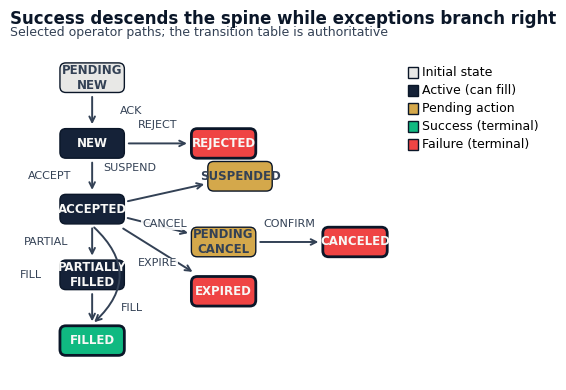

In [13]:
# compliance: skip cell_size - box, arrow, and legend loops share one canvas
def visualize_state_machine():
    """Render selected operator paths from the authoritative transition table."""
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
    ax.set_xlim(-0.5, 13)
    ax.set_ylim(-0.2, 10)
    ax.set_aspect("equal")
    ax.axis("off")
    add_message_title(
        ax,
        "Success descends the spine while exceptions branch right",
        subtitle="Selected operator paths; the transition table is authoritative",
    )

    box_hw, box_hh = 0.95, 0.42
    for state, (x, y) in STATE_POSITIONS.items():
        rect = mpatches.FancyBboxPatch(
            (x - box_hw, y - box_hh),
            2 * box_hw,
            2 * box_hh,
            boxstyle="round,pad=0.03,rounding_size=0.18",
            facecolor=STATE_COLORS[state],
            edgecolor=COLORS["blue"],
            linewidth=2 if state.is_terminal else 1,
        )
        ax.add_patch(rect)
        ax.text(
            x,
            y,
            state.name.replace("_", "\n"),
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="bold",
            color=(
                COLORS["silver"]
                if state
                in {
                    OrderState.NEW,
                    OrderState.ACCEPTED,
                    OrderState.PARTIALLY_FILLED,
                    OrderState.FILLED,
                    OrderState.CANCELED,
                    OrderState.REJECTED,
                    OrderState.EXPIRED,
                }
                else COLORS["neutral"]
            ),
        )

    for from_state, to_state, label in DIAGRAM_TRANSITIONS:
        x1, y1 = STATE_POSITIONS[from_state]
        x2, y2 = STATE_POSITIONS[to_state]
        dx, dy = x2 - x1, y2 - y1
        dist = (dx * dx + dy * dy) ** 0.5
        ux, uy = dx / dist, dy / dist

        pull = box_hw + 0.08 if abs(ux) > abs(uy) else box_hh + 0.08
        sx, sy = x1 + ux * pull, y1 + uy * pull
        ex, ey = x2 - ux * pull, y2 - uy * pull

        arced = (from_state, to_state) == (OrderState.ACCEPTED, OrderState.FILLED)
        connstyle = "arc3,rad=-0.55" if arced else "arc3,rad=0"

        ax.annotate(
            "",
            xy=(ex, ey),
            xytext=(sx, sy),
            arrowprops=dict(
                arrowstyle="->",
                color=COLORS["neutral"],
                lw=1.4,
                connectionstyle=connstyle,
            ),
        )

        label_x, label_y = DIAGRAM_LABEL_POSITIONS[(from_state, to_state)]

        ax.text(
            label_x,
            label_y,
            label,
            fontsize=8,
            color=COLORS["neutral"],
            ha="center",
            va="center",
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 0.5, "alpha": 0.9},
        )

    legend_items = [
        (CATEGORY_COLORS["initial"], "Initial state"),
        (CATEGORY_COLORS["active"], "Active (can fill)"),
        (CATEGORY_COLORS["pending"], "Pending action"),
        (CATEGORY_COLORS["terminal_good"], "Success (terminal)"),
        (CATEGORY_COLORS["terminal_bad"], "Failure (terminal)"),
    ]
    legend_x, legend_y_top = 11.6, 9.0
    for i, (color, label) in enumerate(legend_items):
        ax.add_patch(
            mpatches.Rectangle(
                (legend_x, legend_y_top - i * 0.55),
                0.32,
                0.32,
                facecolor=color,
                edgecolor=COLORS["blue"],
            )
        )
        ax.text(
            legend_x + 0.45,
            legend_y_top + 0.16 - i * 0.55,
            label,
            fontsize=9,
            va="center",
        )

    plt.tight_layout()
    return fig


fig = visualize_state_machine()
plt.show()

**Finding:** The diagram turns the transition table into a visual map of which paths end cleanly and which
end in rejection, cancellation, or expiry.

**Trading implication:** Operations teams need this kind of simplified state map because the same order may
spend time in several active and pending states before the final outcome is known.


## 5. Order History Analysis

Order history analysis shifts the focus from a single order to a portfolio of lifecycle outcomes. That is
closer to how reconciliation and compliance teams inspect real execution logs.

In [14]:
# Create multiple orders with different lifecycles
orders = []

# Order 1: Normal fill
o1 = Order(id="ORD-001", symbol="AAPL", side="buy", qty=100, order_type="market")
o1.apply_event(OrderEvent.ACKNOWLEDGE)
o1.apply_event(OrderEvent.ACCEPT)
o1.apply_event(OrderEvent.FILL, {"qty": 100, "price": 175.50})
orders.append(o1)

# Order 2: Partial fill then cancel
o2 = Order(id="ORD-002", symbol="MSFT", side="buy", qty=200, order_type="limit")
o2.apply_event(OrderEvent.ACKNOWLEDGE)
o2.apply_event(OrderEvent.ACCEPT)
o2.apply_event(OrderEvent.PARTIAL_FILL, {"qty": 75, "price": 380.00})
o2.apply_event(OrderEvent.CANCEL_REQUEST)
o2.apply_event(OrderEvent.CANCEL_CONFIRM)
orders.append(o2)

# Order 3: Rejected
o3 = Order(id="ORD-003", symbol="GOOGL", side="sell", qty=50, order_type="limit")
o3.apply_event(OrderEvent.ACKNOWLEDGE)
o3.apply_event(OrderEvent.REJECT)
orders.append(o3)

# Order 4: Multiple partial fills
o4 = Order(id="ORD-004", symbol="AMZN", side="buy", qty=150, order_type="limit")
o4.apply_event(OrderEvent.ACKNOWLEDGE)
o4.apply_event(OrderEvent.ACCEPT)
o4.apply_event(OrderEvent.PARTIAL_FILL, {"qty": 30, "price": 178.00})
o4.apply_event(OrderEvent.PARTIAL_FILL, {"qty": 50, "price": 178.25})
o4.apply_event(OrderEvent.FILL, {"qty": 70, "price": 178.10})
orders.append(o4)

In [15]:
order_summary = pl.DataFrame(
    [
        {
            "id": o.id,
            "symbol": o.symbol,
            "side": o.side,
            "qty": int(o.qty),
            "filled": int(o.filled_qty),
            "state": o.state.name,
            "transitions": len(o.history),
        }
        for o in orders
    ]
)
order_summary

id,symbol,side,qty,filled,state,transitions
str,str,str,i64,i64,str,i64
"""ORD-001""","""AAPL""","""buy""",100,100,"""FILLED""",3
"""ORD-002""","""MSFT""","""buy""",200,75,"""CANCELED""",5
"""ORD-003""","""GOOGL""","""sell""",50,0,"""REJECTED""",2
"""ORD-004""","""AMZN""","""buy""",150,150,"""FILLED""",5


**Finding:** The summary table makes it clear that identical submission logic can end in fills, cancels,
or rejections depending on the transition path. That is why reconciliation has to inspect lifecycle
history, not just terminal state.

**Trading implication:** Production logs should retain both the final order status and the transition count
so teams can spot unusually long or complex paths before they become operational incidents.


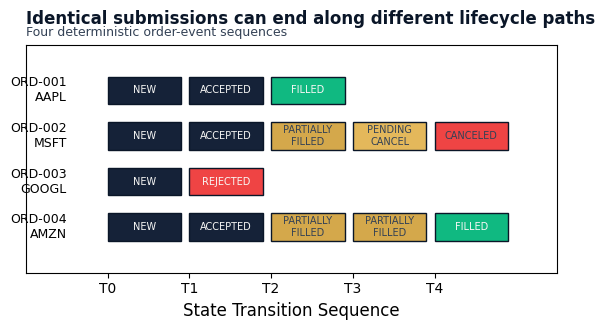

In [16]:
# Visualize order timelines
fig, ax = plt.subplots(figsize=FIGSIZE["single"])

colors_by_state = {
    OrderState.PENDING_NEW: COLORS["silver_muted"],
    OrderState.NEW: COLORS["blue_light"],
    OrderState.ACCEPTED: COLORS["blue_light"],
    OrderState.PARTIALLY_FILLED: COLORS["amber"],
    OrderState.FILLED: COLORS["positive"],
    OrderState.PENDING_CANCEL: COLORS["amber_light"],
    OrderState.CANCELED: COLORS["negative"],
    OrderState.REJECTED: COLORS["negative"],
}

for i, order in enumerate(orders):
    y = len(orders) - i - 1

    # Draw state boxes
    for j, transition in enumerate(order.history):
        color = colors_by_state.get(transition.to_state, COLORS["neutral"])
        rect = mpatches.Rectangle(
            (j, y - 0.3),
            0.9,
            0.6,
            facecolor=color,
            edgecolor=COLORS["blue"],
        )
        ax.add_patch(rect)

        # State name
        name = transition.to_state.name.replace("_", "\n")
        text_color = (
            COLORS["silver"]
            if transition.to_state
            in {OrderState.NEW, OrderState.ACCEPTED, OrderState.FILLED, OrderState.REJECTED}
            else COLORS["neutral"]
        )
        ax.text(
            j + 0.45,
            y,
            name,
            ha="center",
            va="center",
            fontsize=7,
            color=text_color,
        )

    # Order label
    ax.text(-0.5, y, f"{order.id}\n{order.symbol}", ha="right", va="center", fontsize=9)

n_steps = max(len(o.history) for o in orders)
ax.set_xlim(-1, n_steps + 0.5)
ax.set_ylim(-1, len(orders))
ax.set_xlabel("State Transition Sequence", fontsize=12)
add_message_title(
    ax,
    "Identical submissions can end along different lifecycle paths",
    subtitle="Four deterministic order-event sequences",
)
ax.set_yticks([])
ax.set_xticks(range(n_steps))
ax.set_xticklabels([f"T{i}" for i in range(n_steps)])

plt.tight_layout()
plt.show()

**Finding:** The order summary and timeline plots connect each final order state back to its transition
history, which is exactly what reconciliation and compliance reviews require.

**Trading implication:** In production, storing both the current state and the transition path is what lets
teams explain fills, cancels, and rejections after the fact.


## Key Takeaways

- Order management is a controlled transition problem; ten explicit states and a transition table replace
  the ambiguous "open/closed" flag that hides production bugs.
- The `PENDING_CANCEL` state is the canonical example: it makes the cancel-versus-fill race a normal
  transition rather than a reconciliation incident.
- Production systems must persist state and history and deduplicate replayed broker events; this in-memory
  teaching implementation deliberately stops at transition validation.
- Replace flows are out of scope here and live in `ml4t.live.safety`; they layer on top of the lifecycle
  above rather than expanding it.

**Next**: See `04_alpaca_paper_trading_demo.ipynb` and `03_ib_paper_trading_demo.ipynb` to connect lifecycle
rules to actual broker order submission, then review `08_pipeline_verification.ipynb` to see how those
controls fit into the broader Chapter 25 deployment stack.